In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
import os
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

In [2]:
MODEL_NAME = "YOLOv11n"
ANNOTATIONS_CSV = "../data/coco/annotations.csv"
COCO_TO_LABEL = {2: "car", 5: "bus", 7: "truck"}
IOU_THRESHOLD = 0.5
CONF_THRESHOLD = 0.25
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


In [3]:
model = YOLO("yolo11n.pt")
model_size_mb = os.path.getsize(model.ckpt_path) / (1024 ** 2)
print(f"Model size: {model_size_mb:.1f} MB")

Model size: 5.4 MB


In [4]:
gt_df = pd.read_csv(ANNOTATIONS_CSV)
image_paths = gt_df["filepath"].unique().tolist()
print(f"Evaluating on {len(image_paths)} images, {len(gt_df)} ground truth boxes")

Evaluating on 707 images, 2632 ground truth boxes


## Run inference

In [5]:
def compute_iou(box_a, box_b):
    xa = max(box_a[0], box_b[0])
    ya = max(box_a[1], box_b[1])
    xb = min(box_a[2], box_b[2])
    yb = min(box_a[3], box_b[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    return inter / (area_a + area_b - inter + 1e-6)

In [6]:
all_predictions = []
inference_times = []

for path in tqdm(image_paths, desc=f"{MODEL_NAME} inference"):
    t0 = time.perf_counter()
    results = model(
        path,
        conf=CONF_THRESHOLD,
        classes=list(COCO_TO_LABEL.keys()),
        verbose=False,
        device=DEVICE,
    )[0]
    inference_times.append(time.perf_counter() - t0)

    for box in results.boxes:
        cls_id = int(box.cls.item())
        if cls_id not in COCO_TO_LABEL:
            continue
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        all_predictions.append({
            "filepath": path,
            "label": COCO_TO_LABEL[cls_id],
            "conf": box.conf.item(),
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
        })

pred_df = pd.DataFrame(all_predictions, columns=["filepath", "label", "conf", "x1", "y1", "x2", "y2"])
pred_df.to_csv("../data/coco/yolov11_preds.csv", index=False)
avg_fps = 1 / np.mean(inference_times)
print(f"Avg FPS: {avg_fps:.1f} | Total predictions: {len(pred_df)}")

YOLOv11n inference: 100%|██████████| 707/707 [00:23<00:00, 30.59it/s]

Avg FPS: 30.7 | Total predictions: 1897


## Compute precision, recall, F1, mAP@0.5

In [7]:
def evaluate_class(preds, gts, iou_thresh=0.5):
    if preds.empty or gts.empty:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "ap": 0.0}

    preds = preds.sort_values("conf", ascending=False).reset_index(drop=True)
    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))
    matched = set()

    for i, pred in preds.iterrows():
        img_gts = gts[gts["filepath"] == pred["filepath"]]
        best_iou, best_idx = 0, -1
        for j, gt in img_gts.iterrows():
            if j in matched:
                continue
            iou = compute_iou(
                [pred["x1"], pred["y1"], pred["x2"], pred["y2"]],
                [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
            )
            if iou > best_iou:
                best_iou, best_idx = iou, j
        if best_iou >= iou_thresh and best_idx != -1:
            tp[i] = 1
            matched.add(best_idx)
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)
    recalls = cum_tp / (len(gts) + 1e-6)
    precisions = cum_tp / (cum_tp + cum_fp + 1e-6)

    ap = 0
    for t in np.linspace(0, 1, 11):
        p = precisions[recalls >= t]
        ap += p.max() if len(p) else 0
    ap /= 11

    return {
        "precision": float(precisions[-1]),
        "recall": float(recalls[-1]),
        "f1": float(2 * precisions[-1] * recalls[-1] / (precisions[-1] + recalls[-1] + 1e-6)),
        "ap": float(ap),
    }

In [8]:
results_per_class = {}
for cls in ["car", "bus", "truck"]:
    results_per_class[cls] = evaluate_class(
        pred_df[pred_df["label"] == cls],
        gt_df[gt_df["label"] == cls],
        IOU_THRESHOLD,
    )

map50 = np.mean([r["ap"] for r in results_per_class.values()])
print(pd.DataFrame(results_per_class).T.round(4))

       precision  recall      f1      ap
car       0.7055  0.5145  0.5950  0.4925
bus       0.8197  0.7018  0.7561  0.6992
truck     0.6270  0.3687  0.4643  0.3084


## Summary

In [9]:
summary = {
    "model": MODEL_NAME,
    "map50": round(map50, 4),
    "precision": round(np.mean([r["precision"] for r in results_per_class.values()]), 4),
    "recall": round(np.mean([r["recall"] for r in results_per_class.values()]), 4),
    "f1": round(np.mean([r["f1"] for r in results_per_class.values()]), 4),
    "fps": round(avg_fps, 1),
    "model_size_mb": round(model_size_mb, 1),
}
pd.DataFrame([summary]).to_csv("../data/coco/yolov11_results.csv", index=False)

perclass_rows = [{"model": MODEL_NAME, "class": cls, **metrics} for cls, metrics in results_per_class.items()]
pd.DataFrame(perclass_rows).to_csv("../data/coco/yolov11_perclass.csv", index=False)

print(summary)

{'model': 'YOLOv11n', 'map50': np.float64(0.5), 'precision': np.float64(0.7174), 'recall': np.float64(0.5283), 'f1': np.float64(0.6052), 'fps': np.float64(30.7), 'model_size_mb': 5.4}


## Visualize predictions vs ground truth

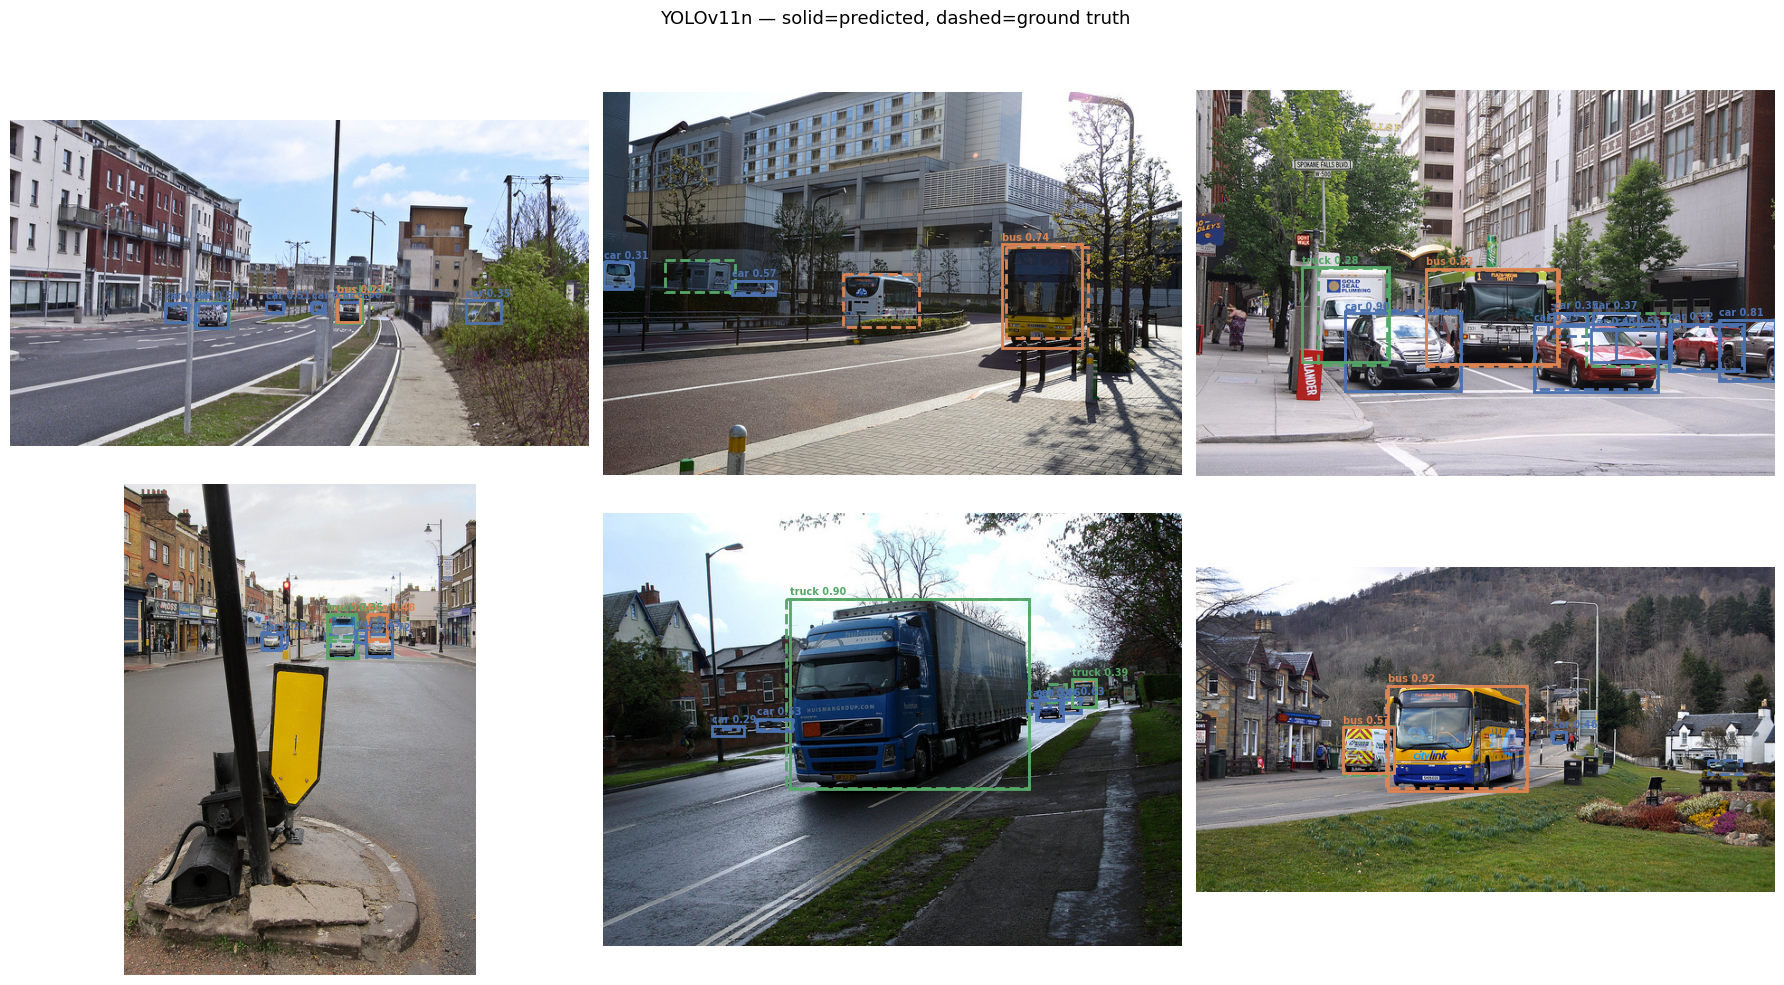

In [10]:
CLASS_COLORS = {"car": "#4C72B0", "bus": "#DD8452", "truck": "#55A868"}
sample_paths = image_paths[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, path in zip(axes.flatten(), sample_paths):
    img = Image.open(path)
    ax.imshow(img)
    for _, gt in gt_df[gt_df["filepath"] == path].iterrows():
        ax.add_patch(patches.Rectangle(
            (gt["x1"], gt["y1"]), gt["x2"] - gt["x1"], gt["y2"] - gt["y1"],
            linewidth=2, edgecolor=CLASS_COLORS.get(gt["label"], "white"), facecolor="none", linestyle="--"
        ))
    for _, pred in pred_df[pred_df["filepath"] == path].iterrows():
        ax.add_patch(patches.Rectangle(
            (pred["x1"], pred["y1"]), pred["x2"] - pred["x1"], pred["y2"] - pred["y1"],
            linewidth=2, edgecolor=CLASS_COLORS.get(pred["label"], "red"), facecolor="none"
        ))
        ax.text(pred["x1"], pred["y1"] - 4, f"{pred['label']} {pred['conf']:.2f}",
                color=CLASS_COLORS.get(pred["label"], "red"), fontsize=7, fontweight="bold")
    ax.axis("off")

plt.suptitle(f"{MODEL_NAME} — solid=predicted, dashed=ground truth", fontsize=13)
plt.tight_layout()
plt.savefig("../data/coco/yolov11_predictions.png", dpi=150, bbox_inches="tight")
plt.show()